In [1]:
import os
import sys
sys.path.insert(0, "../..")

import ast
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

from src.constants import C2A_PALETTE, DATA_PATH
plt.rcParams['figure.dpi'] = 300

/home/aliaagheis/miniconda3/envs/fast_env/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 1 - Loading and Preprocessing Grounder Results DF

In [2]:
def parse_annotation(df):
    parsed = df['annotation'].apply(ast.literal_eval)
    df['img_filename'] = parsed.apply(lambda x: x['img_filename'])
    df['bbox']         = parsed.apply(lambda x: x['bbox'])        # [x1, y1, x2, y2] absolute pixels
    df['img_size']     = parsed.apply(lambda x: x['img_size'])    # [W, H]
    df['ui_type']      = parsed.apply(lambda x: x['ui_type'])
    df['application']  = parsed.apply(lambda x: x['application'])
    df['platform']     = parsed.apply(lambda x: x['platform'])
    return df

def point_in_bbox(row):
    W, H = row['img_size']                                                                                                                                    
    px = row['coord_x'] * W
    py = row['coord_y'] * H                                                                                                                                   
    x1, y1, x2, y2 = row['bbox']
    return x1 <= px <= x2 and y1 <= py <= y2           

In [3]:
results = pd.read_csv("grounder.csv", index_col=0)

In [4]:
results[results['coord_x'].isna()]

,task,coord_x,coord_y,action_type,text,raw_output,annotation
idx,,,,,,,


In [5]:
results         = results[~results['coord_x'].isna()]
results         = parse_annotation(results)
results['hit']  = results.apply(point_in_bbox, axis=1)

results['app/platform'] = results.apply(lambda r: r['application'] + f" ({r['platform']})", axis=1)
results['img_area']     = results.apply(lambda r: r['img_size'][0]*r['img_size'][1], axis=1)
results['bbox_area']    = results.apply(lambda r: (r['bbox'][2] - r['bbox'][0])*(r['bbox'][3] - r['bbox'][1]), axis=1)

In [6]:
results['hit'].value_counts()

hit
False    617
True     415
Name: count, dtype: int64

## Visualization

### Utils/Plot/Vis Functions

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle, Circle

DATASET_ROOT = DATA_PATH / "raw" / "screenspot_pro" / "images"

def visualize_row(row, radius=4, bbox_line_width=3, circle_line_width=1.5, fontsize=8, save_file_path = None):
    W, H = row["img_size"]
    px, py = row["coord_x"] * W, row["coord_y"] * H
    bx1, by1, bx2, by2 = row["bbox"]
    img = Image.open(f"{DATASET_ROOT}/{row['img_filename']}")

    fig, ax = plt.subplots(figsize=(14, 14 * H / W))
    ax.imshow(img)
    ax.axis("off")

    # bbox: fill + outline
    ax.add_patch(Rectangle(
        (bx1, by1), bx2 - bx1, by2 - by1,
        facecolor=(*[int(C2A_PALETTE["tertiary"][i:i+2], 16)/255 for i in (1, 3, 5)], 0.2),
        edgecolor=C2A_PALETTE["tertiary"], linewidth=bbox_line_width,
    ))

    # click: big translucent circle + outline
    ax.plot(px, py, "r+", markersize=radius, markeredgewidth=circle_line_width)
    ax.plot(px, py, "o", markersize=radius, markeredgewidth=circle_line_width, markerfacecolor="none", markeredgecolor="red")

    # task: yellow box in top-left with arrow to bbox
    xmid, ymid = (bx1 + bx2)/2, (by1 + by2)/2
    xtext = xmid + 100 if xmid + 100 < W else xmid - 100 
    ytext = ymid - 100 if ymid - 100 > H else ymid + 100 
    ax.annotate(
        f"{row['task']}",
        xy=(xmid, ymid),
        xytext=(xtext, ytext),
        arrowprops=dict(arrowstyle="->", color=C2A_PALETTE["tertiary"]),
        bbox=dict(boxstyle="round,pad=0.3", facecolor=C2A_PALETTE["tertiary"], alpha=0.7),
        fontsize=fontsize,
    )


    plt.tight_layout()
    if save_file_path:
        plt.savefig(f"./results/samples/{save_file_path}")
    else:
        plt.show()


### Visualize ScreenSpot-Pro dataset

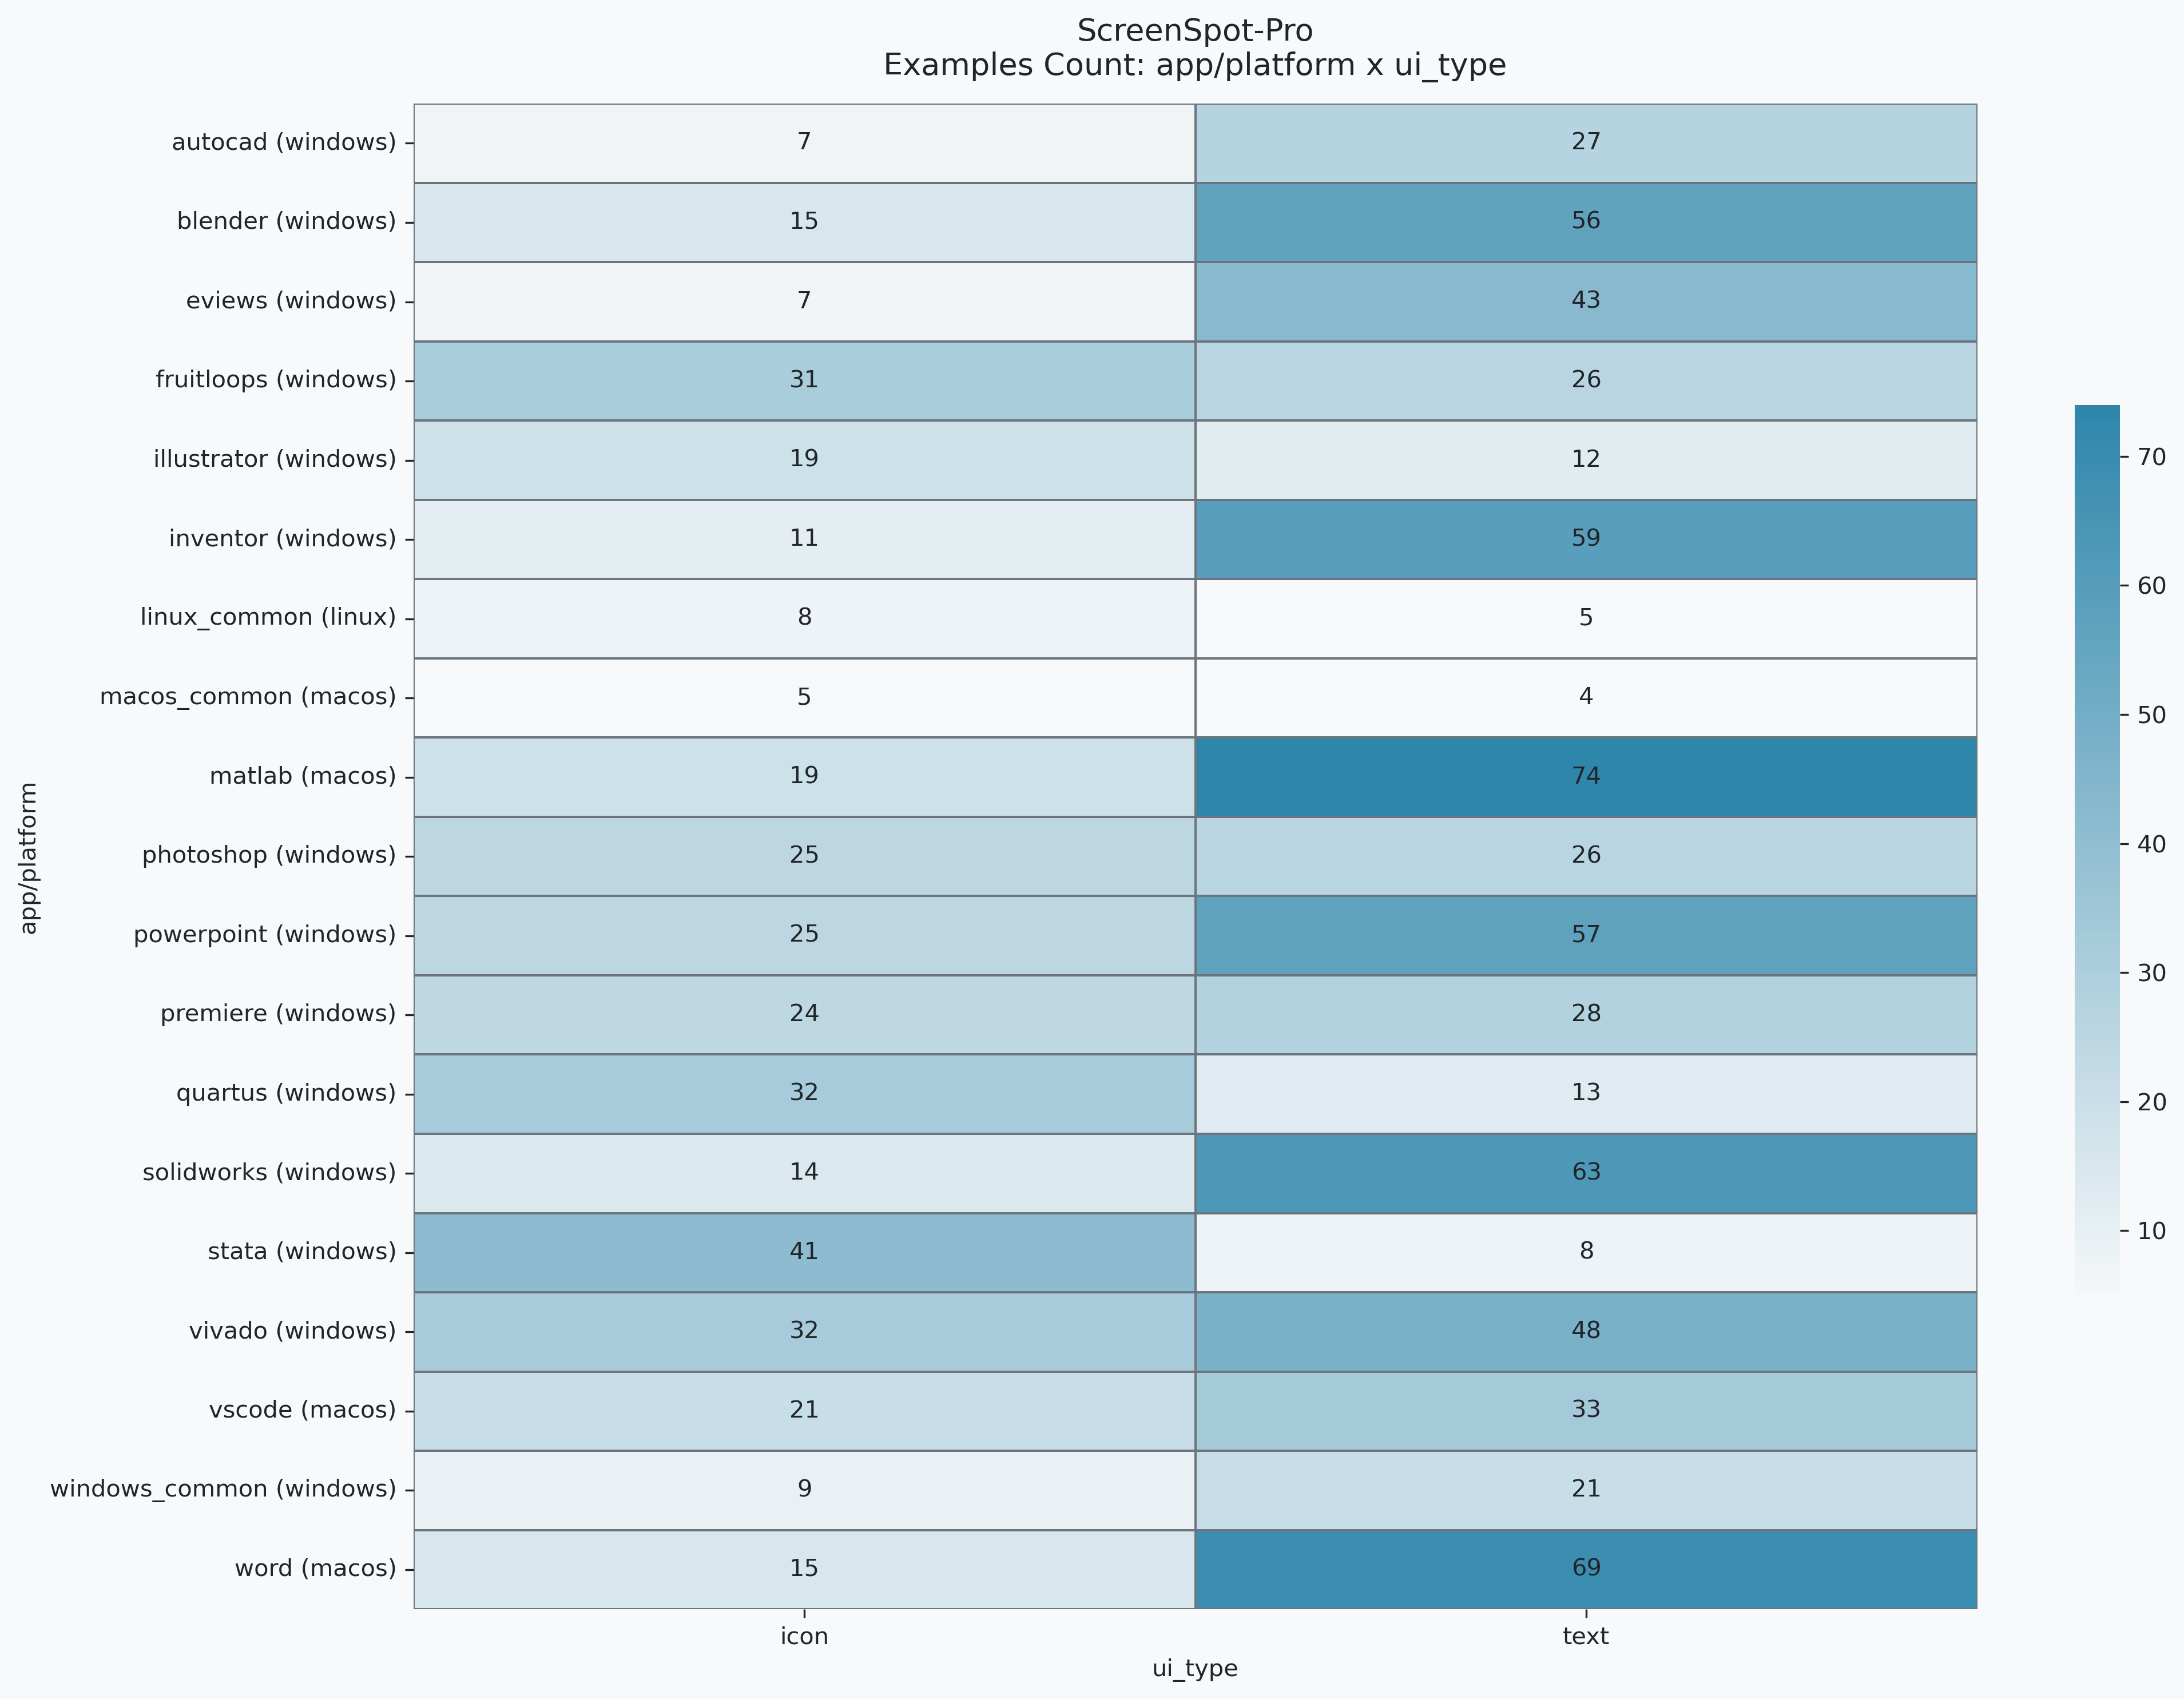

In [9]:

def plot_screenspot_pro_dist(df, figsize=(14, 10)):
    pivot = df.groupby(['app/platform', 'ui_type']).size().unstack(fill_value=0)

    cmap = mcolors.LinearSegmentedColormap.from_list(
        "c2a", [C2A_PALETTE["bg"], C2A_PALETTE["primary"]]
    )

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    sns.heatmap(
        pivot,
        annot=True,
        fmt="d",
        cmap=cmap,
        linewidths=0.5,
        linecolor=C2A_PALETTE["neutral"],
        ax=ax,
        annot_kws={"color": C2A_PALETTE["text"], "size": 10},
        cbar_kws={"shrink": 0.6},
    )

    ax.set_title("ScreenSpot-Pro\nExamples Count: app/platform x ui_type", color=C2A_PALETTE["text"], fontsize=13, pad=12)
    ax.set_xlabel("ui_type", color=C2A_PALETTE["text"])
    ax.set_ylabel("app/platform", color=C2A_PALETTE["text"])
    ax.tick_params(colors=C2A_PALETTE["text"])
    ax.xaxis.label.set_color(C2A_PALETTE["text"])
    ax.yaxis.label.set_color(C2A_PALETTE["text"])
    plt.setp(ax.get_xticklabels(), color=C2A_PALETTE["text"])
    plt.setp(ax.get_yticklabels(), color=C2A_PALETTE["text"], rotation=0)
    ax.collections[0].colorbar.ax.tick_params(colors=C2A_PALETTE["text"])

    plt.tight_layout()
    # plt.savefig("./results/screenspot-pro-examples-counts.png")
    plt.show()

plot_screenspot_pro_dist(results)

### Init Visualization of Failed Examples

In [11]:
# res_path = Path("./results/samples/")
# count = 0
# count_tot = 0
# for pth in list(res_path.rglob("*.jpeg")):
#     count += str(pth.parent) != "results/samples"
#     count_tot += str(pth.parent) == "results/samples"
    
# count, count_tot

In [12]:
# from tqdm.auto import tqdm
# for row in tqdm(results[~results['hit']].sample(frac=1).iterrows()):
#     visualize_row(row[1], radius=8, save_file_path=f"failed_{row[0]}.png")

In [14]:
results['hit'].mean()

np.float64(0.4021317829457364)

In [15]:
print((results.groupby('app/platform')['hit'].mean().sort_values()[::-1] * 100).to_markdown())

| app/platform             |     hit |
|:-------------------------|--------:|
| eviews (windows)         | 74      |
| powerpoint (windows)     | 64.6341 |
| word (macos)             | 61.9048 |
| linux_common (linux)     | 61.5385 |
| macos_common (macos)     | 55.5556 |
| matlab (macos)           | 53.7634 |
| vivado (windows)         | 51.25   |
| photoshop (windows)      | 39.2157 |
| illustrator (windows)    | 38.7097 |
| quartus (windows)        | 35.5556 |
| windows_common (windows) | 33.3333 |
| vscode (macos)           | 33.3333 |
| premiere (windows)       | 30.7692 |
| blender (windows)        | 28.169  |
| stata (windows)          | 24.4898 |
| inventor (windows)       | 24.2857 |
| fruitloops (windows)     | 22.807  |
| autocad (windows)        | 17.6471 |
| solidworks (windows)     | 11.6883 |


In [16]:
print((results.groupby('ui_type')['hit'].mean().sort_values()[::-1] * 100).to_markdown())

| ui_type   |     hit |
|:----------|--------:|
| text      | 50.4464 |
| icon      | 21.1111 |


In [17]:
print((results.groupby('platform')['hit'].mean().sort_values()[::-1] * 100).to_markdown())

| platform   |     hit |
|:-----------|--------:|
| linux      | 61.5385 |
| macos      | 52.0833 |
| windows    | 36.2003 |


In [18]:
results.groupby('ui_type')['hit'].mean().sort_values()[::-1]

ui_type
text    0.504464
icon    0.211111
Name: hit, dtype: float64

In [19]:
results.groupby('platform')['hit'].mean().sort_values()[::-1]

platform
linux      0.615385
macos      0.520833
windows    0.362003
Name: hit, dtype: float64

In [20]:
# results.apply(lambda r: print(r))

In [21]:
results.groupby('app/platform')['hit'].mean().sort_values()[::-1]

app/platform
eviews (windows)            0.740000
powerpoint (windows)        0.646341
word (macos)                0.619048
linux_common (linux)        0.615385
macos_common (macos)        0.555556
matlab (macos)              0.537634
vivado (windows)            0.512500
photoshop (windows)         0.392157
illustrator (windows)       0.387097
quartus (windows)           0.355556
windows_common (windows)    0.333333
vscode (macos)              0.333333
premiere (windows)          0.307692
blender (windows)           0.281690
stata (windows)             0.244898
inventor (windows)          0.242857
fruitloops (windows)        0.228070
autocad (windows)           0.176471
solidworks (windows)        0.116883
Name: hit, dtype: float64

In [22]:
results.groupby('img_area')['hit'].mean().sort_values()[::-1]

img_area
5184000    0.646341
7464960    0.615385
3110400    0.494949
3686400    0.429961
4259840    0.375000
5595040    0.375000
2073600    0.368421
7372800    0.360656
4096000    0.285714
4147200    0.176796
Name: hit, dtype: float64

### Visualization of Hit Patterns

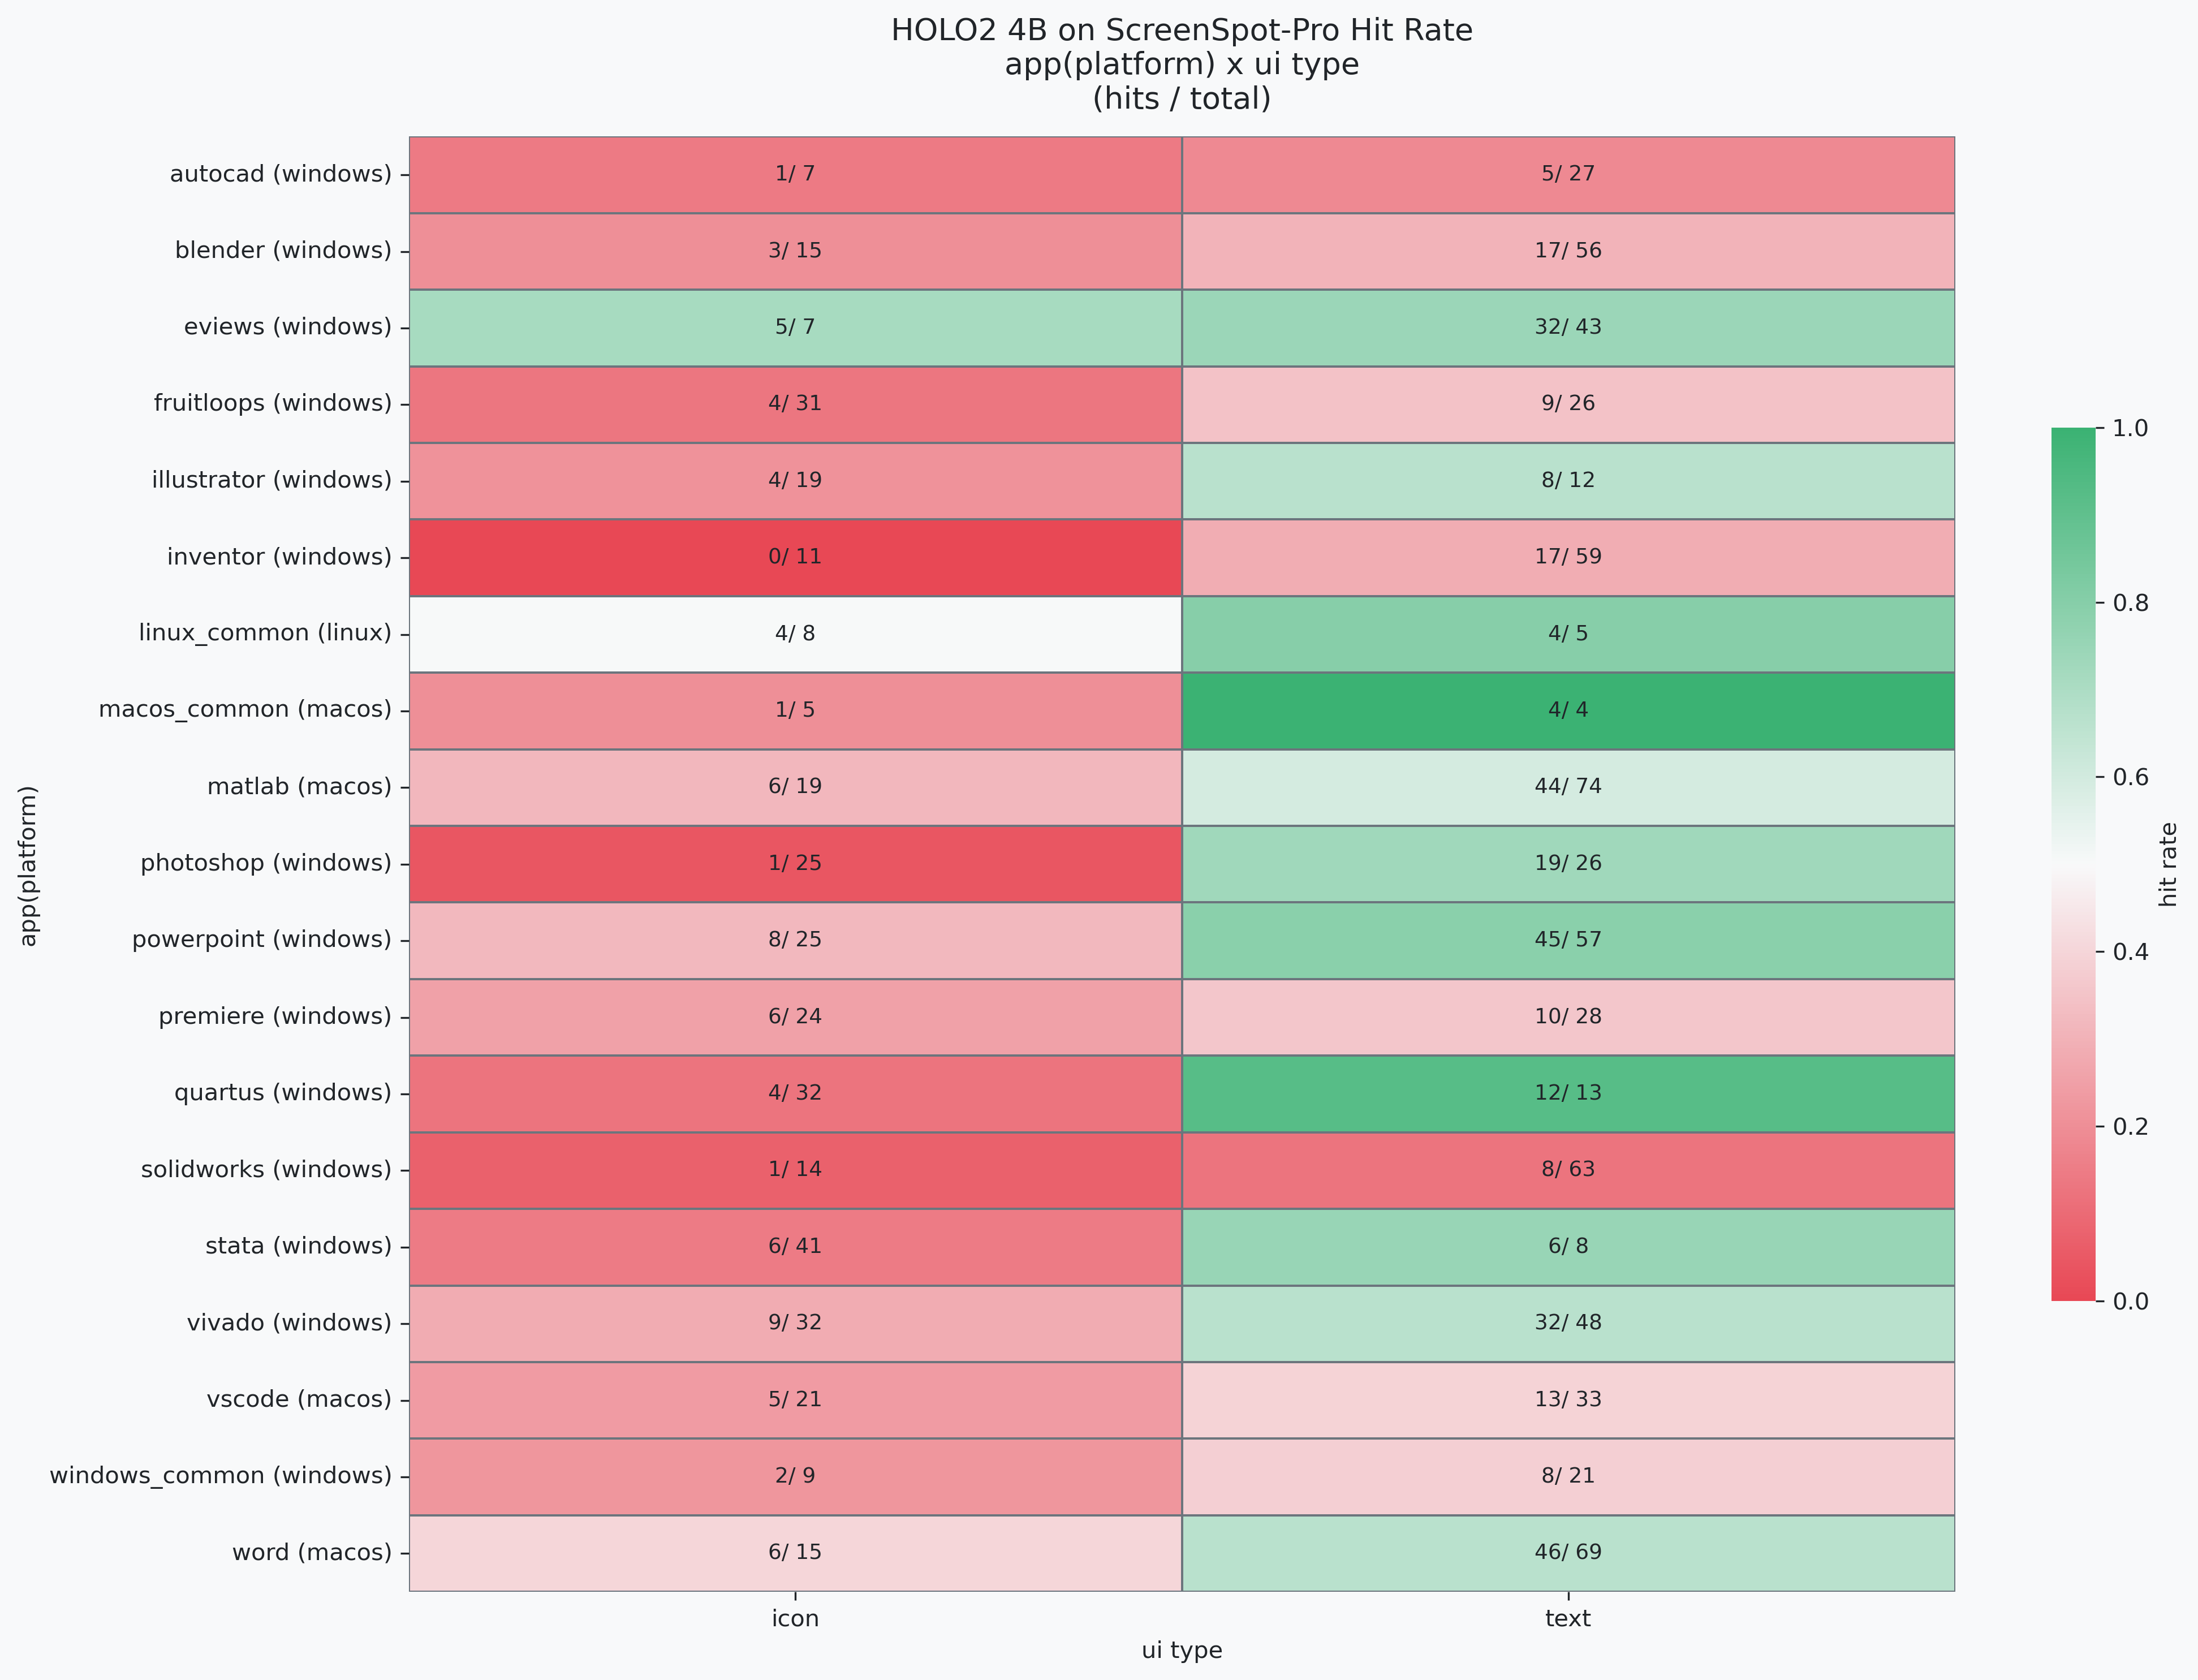

In [25]:

def plot_hit_heatmap(df, figsize=(14, 10)):
    grp    = df.groupby(['app/platform', 'ui_type'])['hit']
    hits   = grp.sum().unstack(fill_value=0)
    totals = grp.count().unstack(fill_value=0)
    rates  = (hits / totals.replace(0, float('nan'))).fillna(0)

    # annotation: "hits/total"
    annot = hits.astype(int).astype(str) + "/ " + totals.astype(int).astype(str)

    cmap = mcolors.LinearSegmentedColormap.from_list(
        "c2a_hit", [C2A_PALETTE["warning"], C2A_PALETTE["bg"], C2A_PALETTE["success"]]
    )

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    sns.heatmap(
        rates,
        annot=annot,
        fmt="",
        cmap=cmap,
        vmin=0, vmax=1,
        linewidths=0.5,
        linecolor=C2A_PALETTE["neutral"],
        ax=ax,
        annot_kws={"color": C2A_PALETTE["text"], "size": 9},
        cbar_kws={"shrink": 0.6, "label": "hit rate"},
    )

    ax.set_title("HOLO2 4B on ScreenSpot-Pro Hit Rate\napp(platform) x ui type\n(hits / total)", color=C2A_PALETTE["text"], fontsize=13, pad=12)
    ax.set_xlabel("ui type", color=C2A_PALETTE["text"])
    ax.set_ylabel("app(platform)", color=C2A_PALETTE["text"])
    plt.setp(ax.get_xticklabels(), color=C2A_PALETTE["text"])
    plt.setp(ax.get_yticklabels(), color=C2A_PALETTE["text"], rotation=0)
    ax.tick_params(colors=C2A_PALETTE["text"])
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(colors=C2A_PALETTE["text"])
    cbar.ax.yaxis.label.set_color(C2A_PALETTE["text"])

    plt.tight_layout()
    plt.savefig("./results/holo2-screenspot-pro-examples-hit-rate-counts.png")
    plt.show()

plot_hit_heatmap(results)

In [138]:
# results[(results['application'] == 'word') & (results['ui_type'] == 'icon') & (results['hit'] == False)]

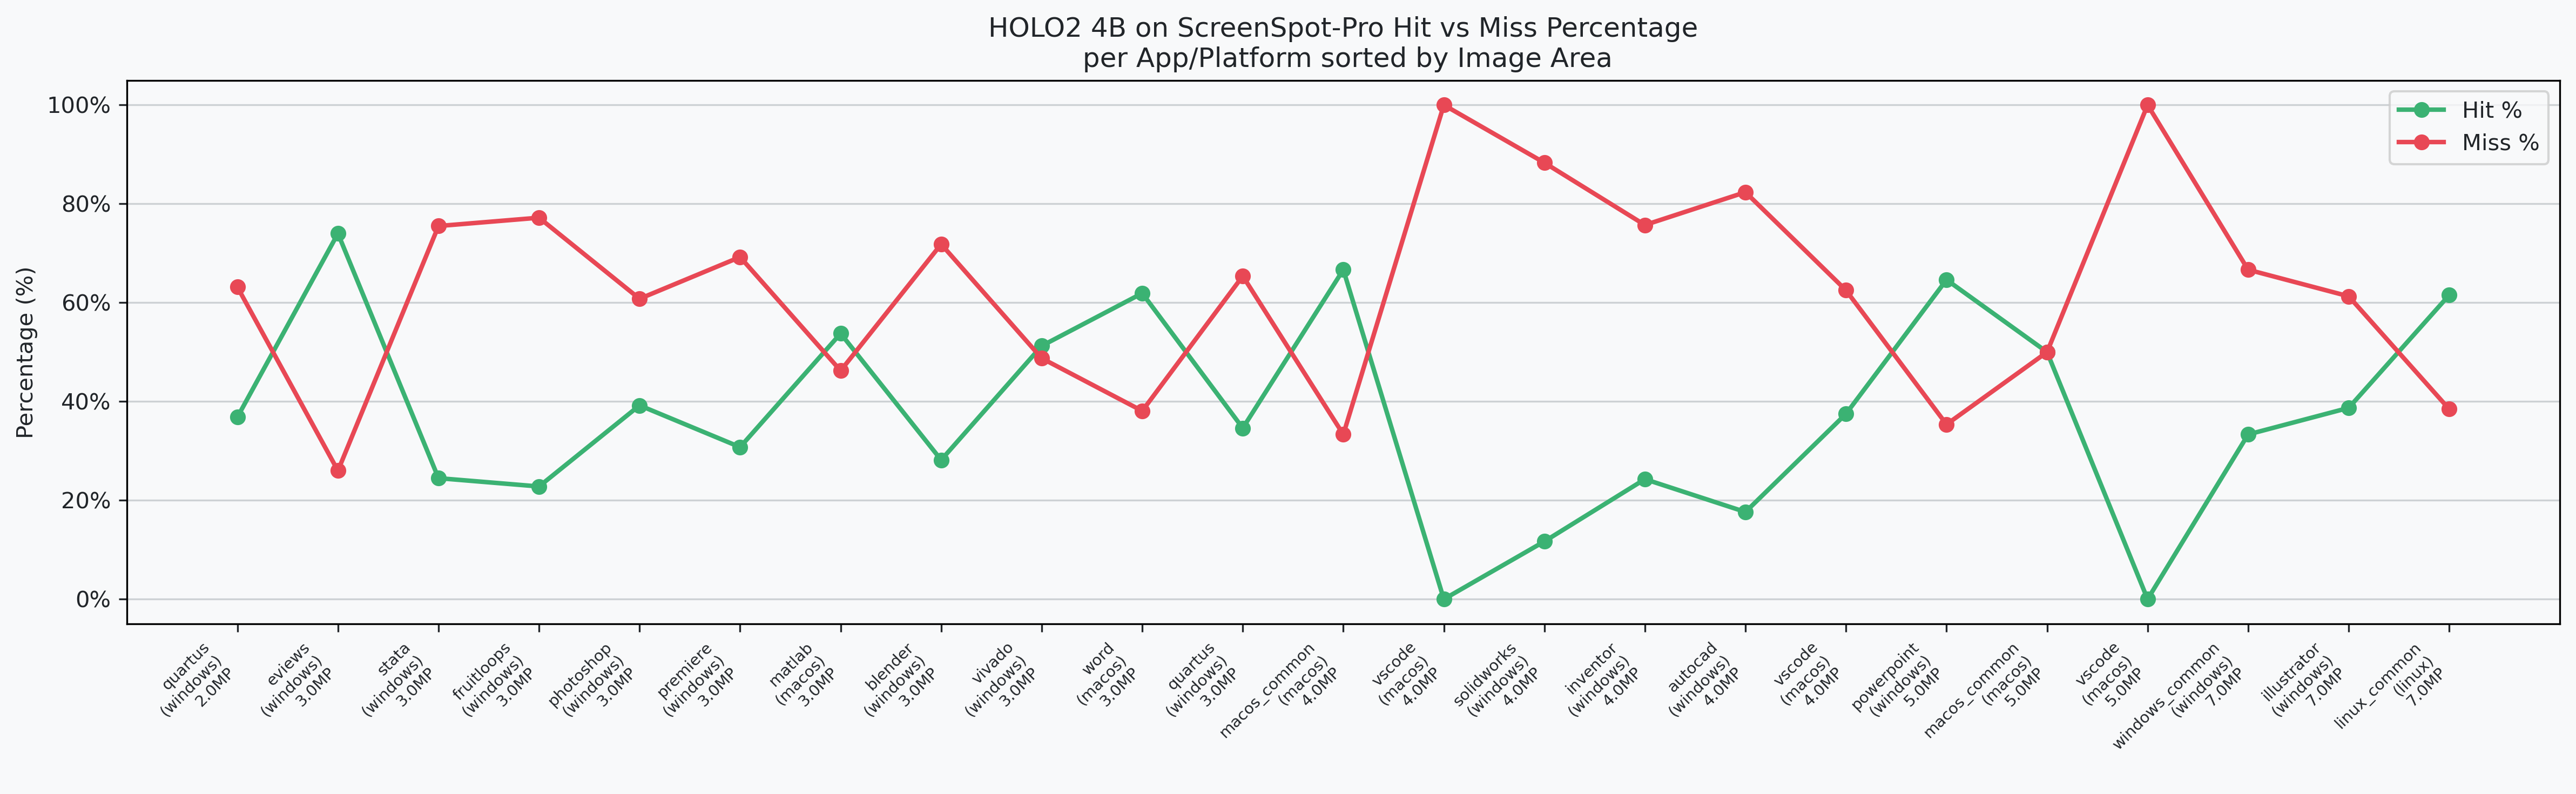

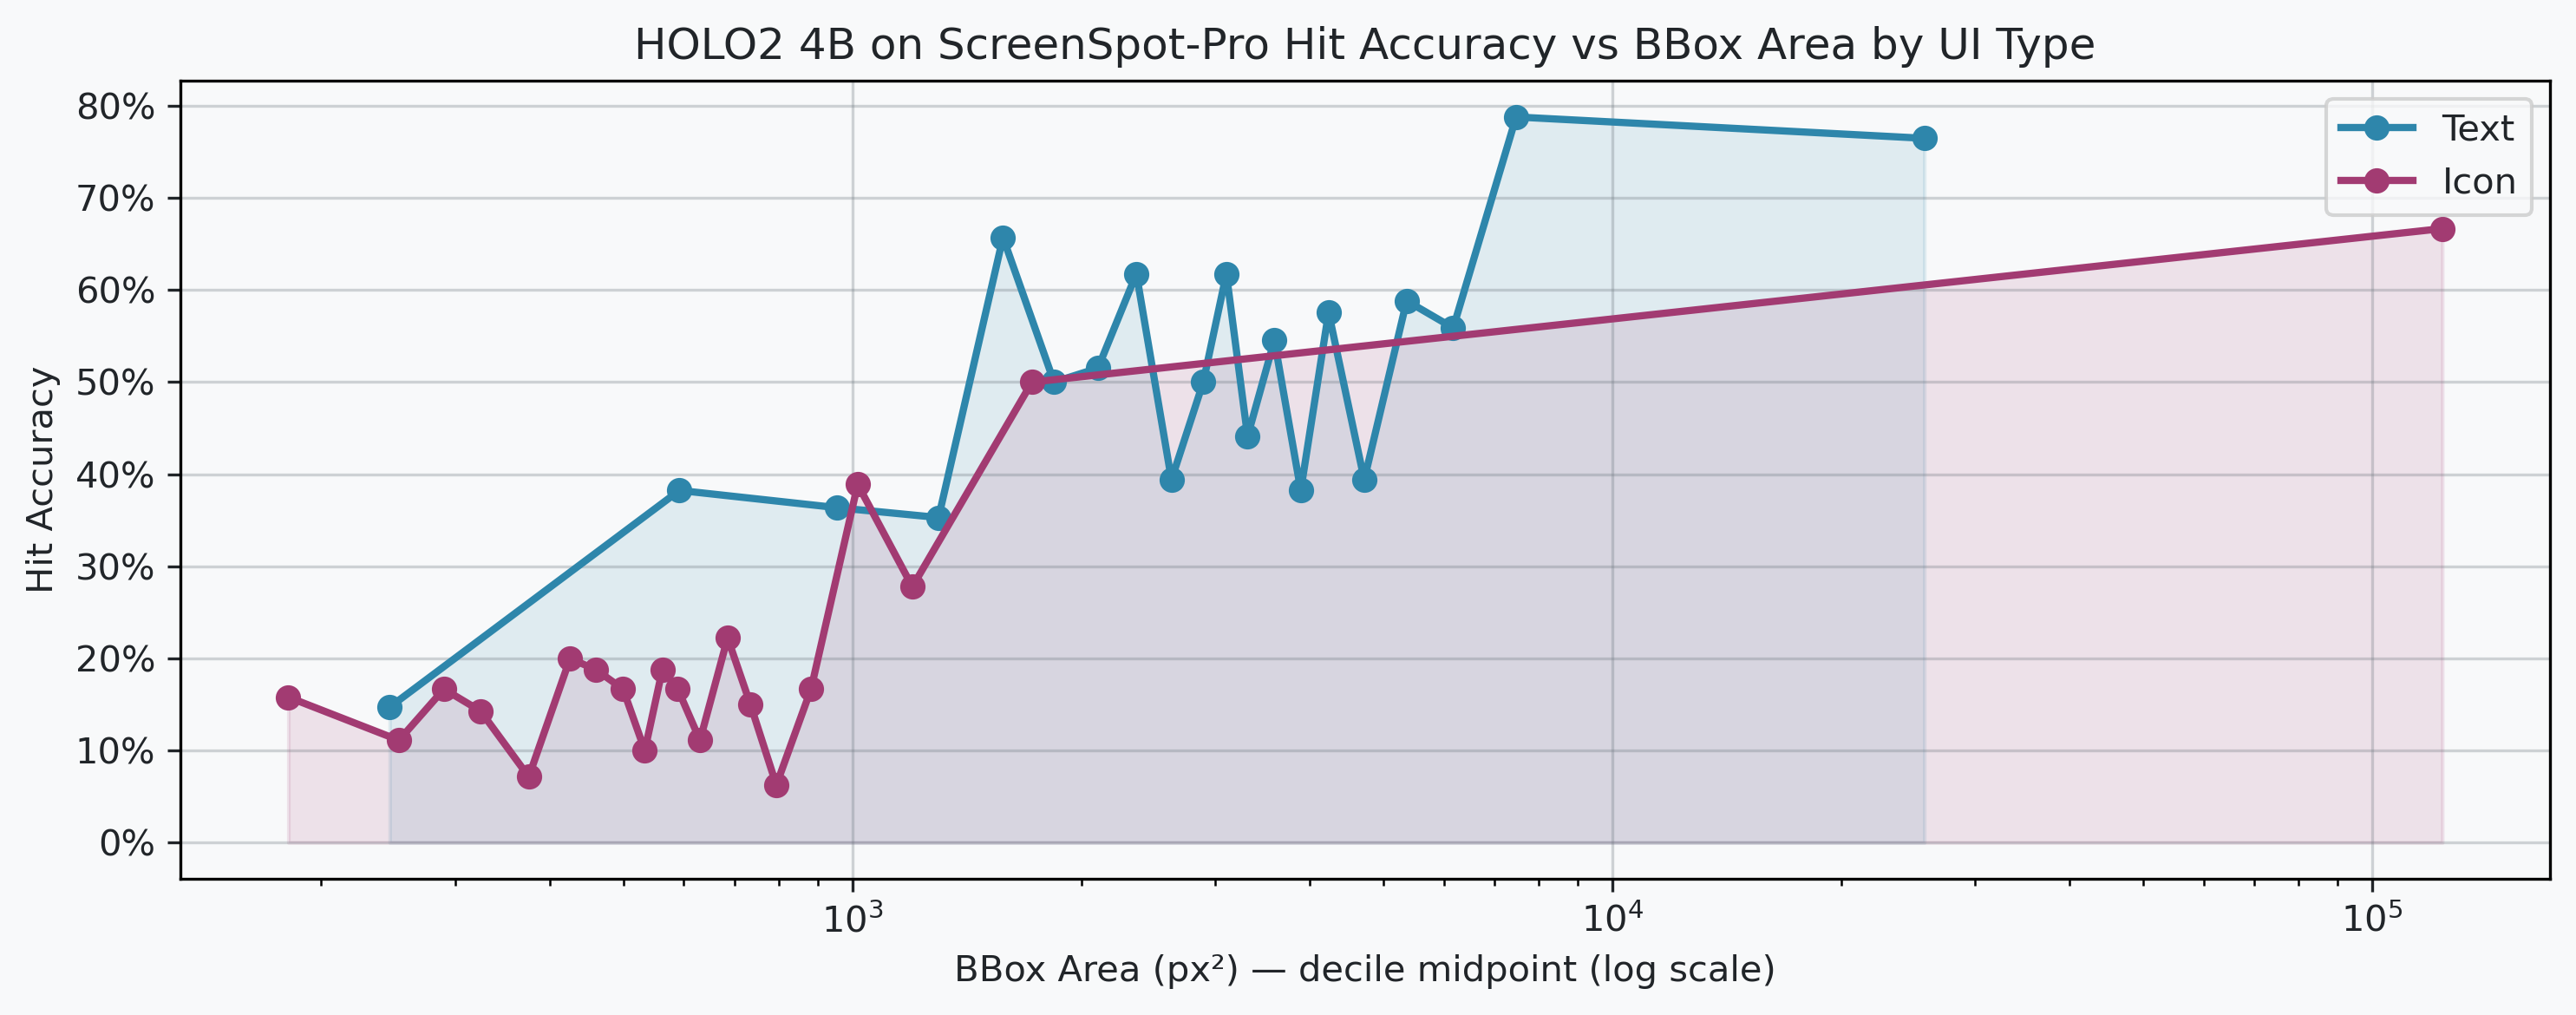

In [26]:
def plot_hit_miss_pct_by_img_area(df):
    # Group and aggregate properly to get raw counts first
    grp = df.groupby(['application', 'platform', 'img_area'])['hit']
    summary = grp.agg(hit='sum', total='count').reset_index()
    summary['miss'] = summary['total'] - summary['hit']
    
    # --- Calculate Percentages ---
    summary['hit_pct'] = (summary['hit'] / summary['total']) * 100
    summary['miss_pct'] = (summary['miss'] / summary['total']) * 100
    
    summary = summary.sort_values('img_area')
    summary['label'] = summary.apply(
        lambda r: f"{r['application']}\n({r['platform']})\n{r['img_area']//1_000_000:.1f}MP", axis=1
    )

    fig, ax = plt.subplots(figsize=(16, 5))
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])
    x = range(len(summary))
    
    # --- Plot the percentage columns instead of raw counts ---
    ax.plot(x, summary['hit_pct'],  marker='o', color=C2A_PALETTE["success"], label='Hit %',  linewidth=2)
    ax.plot(x, summary['miss_pct'], marker='o', color=C2A_PALETTE["warning"], label='Miss %', linewidth=2)
    
    ax.set_xticks(list(x))
    ax.set_xticklabels(summary['label'], fontsize=7, color=C2A_PALETTE["text"], rotation=45, ha='right')
    
    # --- Update Labels and Y-axis Formatting ---
    ax.set_ylabel("Percentage (%)", color=C2A_PALETTE["text"])
    ax.set_title("HOLO2 4B on ScreenSpot-Pro Hit vs Miss Percentage\n per App/Platform sorted by Image Area", color=C2A_PALETTE["text"], fontsize=12)
    ax.tick_params(colors=C2A_PALETTE["text"])
    
    # Set y-axis from 0 to 100 and add % formatting
    ax.set_ylim(-5, 105) # Added slight padding so dots don't clip at exactly 0 or 100
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
    
    ax.legend(facecolor=C2A_PALETTE["bg"], labelcolor=C2A_PALETTE["text"])
    ax.grid(axis='y', color=C2A_PALETTE["neutral"], alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("./results/holo2-screenspot-pro-hit-miss-perct-per-app-img-area.png")
    plt.show()

def plot_accuracy_by_bbox_area(df, n_bins=10):
    ui_styles = {
        "text": {"color": C2A_PALETTE["primary"],   "label": "Text"},
        "icon": {"color": C2A_PALETTE["secondary"],  "label": "Icon"},
    }

    fig, ax = plt.subplots(figsize=(10, 4))
    fig.patch.set_facecolor(C2A_PALETTE["bg"])
    ax.set_facecolor(C2A_PALETTE["bg"])

    for ui_type, style in ui_styles.items():
        subset = df[df['ui_type'] == ui_type].copy()
        subset['bbox_area_bin'] = pd.qcut(subset['bbox_area'], q=n_bins, duplicates='drop')
        bin_acc = subset.groupby('bbox_area_bin', observed=True)['hit'].mean().reset_index()
        bin_acc['bin_mid'] = bin_acc['bbox_area_bin'].apply(lambda b: int(b.mid))

        ax.plot(
            bin_acc['bin_mid'], bin_acc['hit'],
            marker='o', color=style["color"], linewidth=2, label=style["label"]
        )
        ax.fill_between(bin_acc['bin_mid'], bin_acc['hit'], alpha=0.12, color=style["color"])

    ax.set_xscale('log')
    ax.set_xlabel("BBox Area (px²) — decile midpoint (log scale)", color=C2A_PALETTE["text"])
    ax.set_ylabel("Hit Accuracy", color=C2A_PALETTE["text"])
    ax.set_title("HOLO2 4B on ScreenSpot-Pro Hit Accuracy vs BBox Area by UI Type", color=C2A_PALETTE["text"], fontsize=12)
    ax.tick_params(colors=C2A_PALETTE["text"])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(color=C2A_PALETTE["neutral"], alpha=0.3)
    ax.legend(facecolor=C2A_PALETTE["bg"], labelcolor=C2A_PALETTE["text"])

    plt.tight_layout()
    plt.savefig("./results/holo2-screenspot-pro-hit-acc-vs-bbox-area.png")
    plt.show()



plot_hit_miss_pct_by_img_area(results)
plot_accuracy_by_bbox_area(results, 20)